## Data Visualization

In [1]:
# Load the libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
data_url = "https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/"
df = pd.read_csv(data_url + "telecom_churn.csv")

In [3]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df["Churn"] = df["Churn"].astype("int")
df["Churn"].head()

0    0
1    0
2    0
3    0
4    0
Name: Churn, dtype: int64

The easiest way to see the distribution of numerical variables is histogram. We can learn many thing by histogram

array([[<Axes: title={'center': 'Total day minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>]], dtype=object)

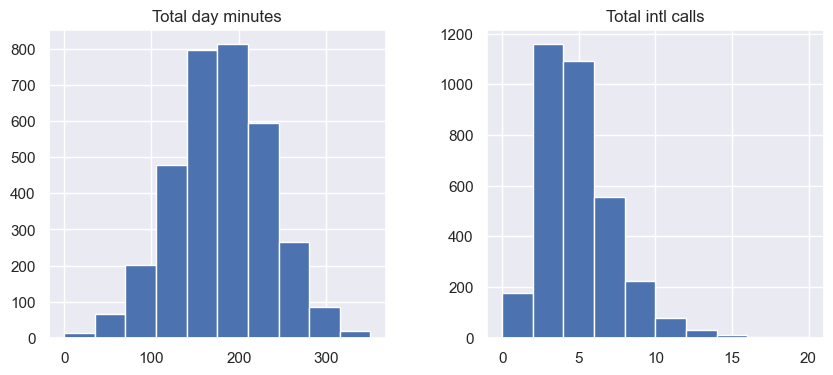

In [5]:
features = ["Total day minutes","Total intl calls"]
df[features].hist(figsize=(10,4))

Another is the kernel density plot

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

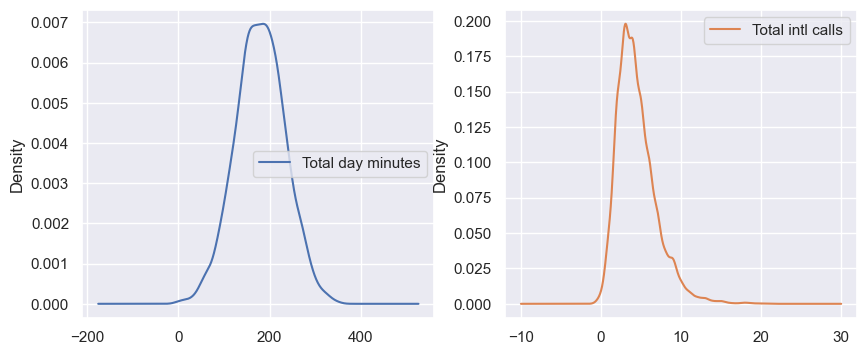

In [6]:
df[features].plot(kind="density",subplots=True,layout=(1,2),sharex=False,figsize=(10,4))

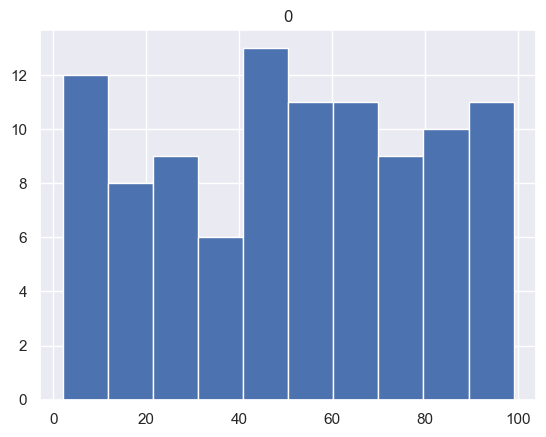

In [7]:
# Example
x = np.random.randint(low = 1,high = 100,size = 100)
x = pd.DataFrame(x).hist()

<Axes: xlabel='Total day calls', ylabel='Density'>

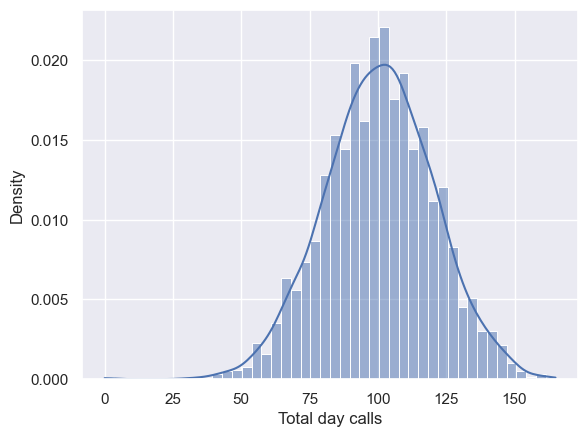

In [8]:
# With seaborn
sns.histplot(df["Total day calls"],kde = True,stat="density")

<Axes: xlabel='Churn', ylabel='Count'>

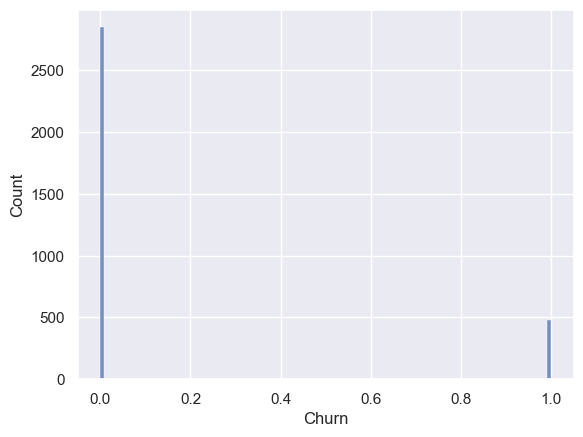

In [9]:
sns.histplot(df["Churn"],stat="count")

Box plot

<Axes: xlabel='Total day calls'>

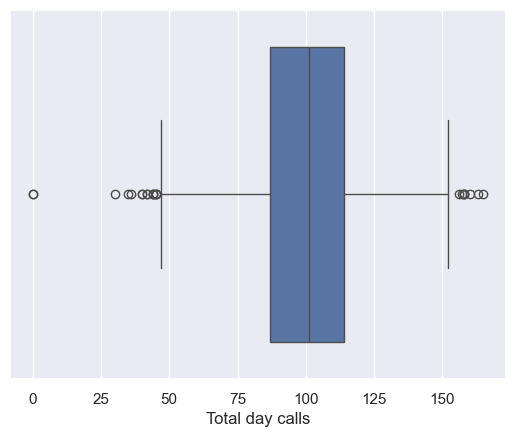

In [10]:
sns.boxplot(x = "Total day calls",data = df)

<Axes: >

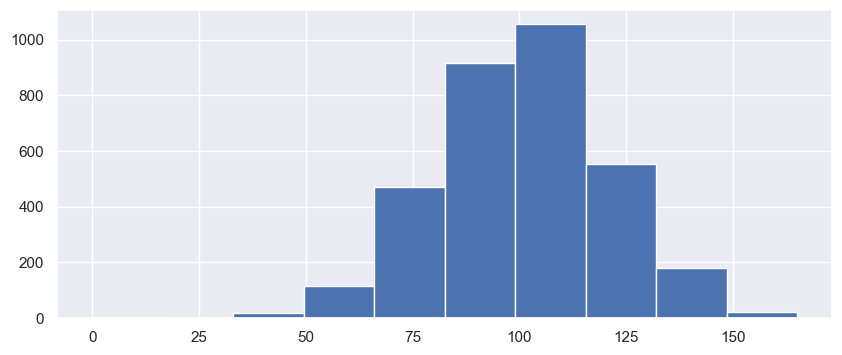

In [11]:
df["Total day calls"].hist(figsize=(10,4))

Violin plots:
The difference between the box and violin plots is that the former illustrates certain statistics concerning individual examples in a dataset while the violin plot concentrates more on the smoothed distribution as a whole.

<Axes: ylabel='Total intl calls'>

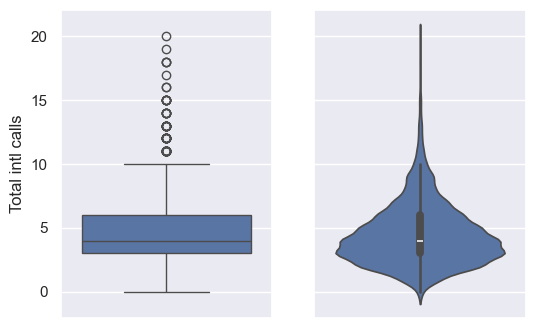

In [12]:
_,axes = plt.subplots(1,2,sharey=True,figsize = (6,4))
sns.boxplot(data = df["Total intl calls"],ax=axes[0])
sns.violinplot(data = df["Total intl calls"],ax = axes[1])

Another way to visualize data is describe() method so we can use describe

In [13]:
df[features].describe().T

,count,mean,std,min,25%,50%,75%,max
Total day minutes,3333.0,179.775098,54.467389,0.0,143.7,179.4,216.4,350.8
Total intl calls,3333.0,4.479448,2.461214,0.0,3.0,4.0,6.0,20.0


## Categorical and Binary Features
Categorical features take on a fixed number of values. Each of these values assigns an observation to a corresponding group, known as a category, which reflects some qualitative property of this example. Binary variables are an important special case of categorical variables when the number of possible values is exactly 2. If the values of a categorical variable are ordered, it is called ordinal.

In [14]:
df["Churn"].value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

Barplot: It is a graphical representation of frequency distribution

<Axes: xlabel='Customer service calls', ylabel='count'>

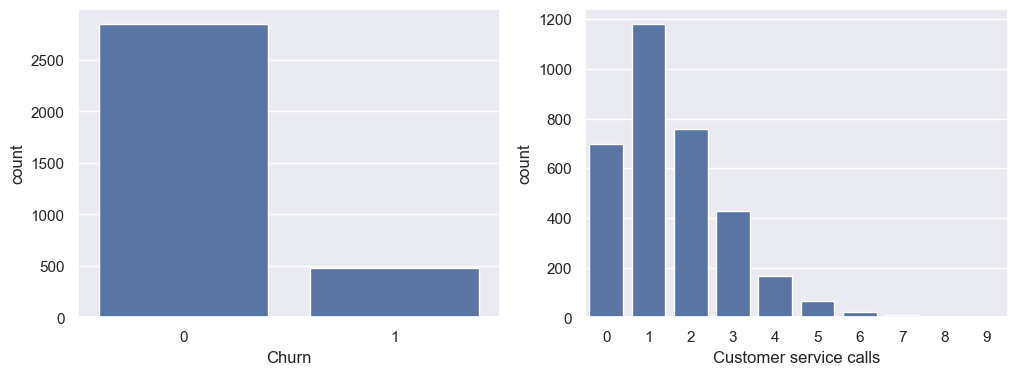

In [15]:
_,axes = plt.subplots(nrows=1,ncols=2,figsize = (12,4))
sns.countplot(x = "Churn",data = df,ax=axes[0])
sns.countplot(x = "Customer service calls",data = df,ax = axes[1])

In [16]:
d = {"No":0,"Yes":1}
df["International plan"] = df["International plan"].map(d)

<Axes: xlabel='International plan', ylabel='count'>

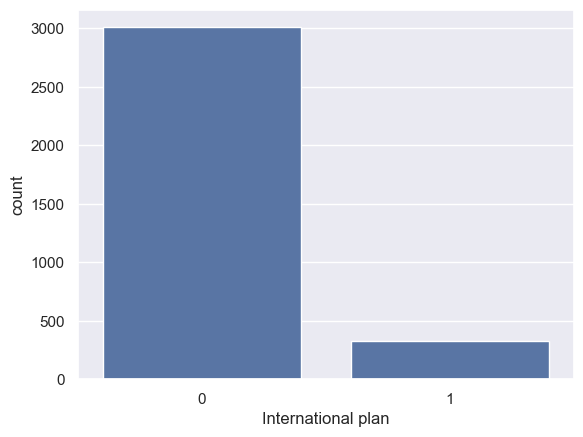

In [17]:
sns.countplot(x ="International plan",data = df)

# Multivariate Visualization
Multivariate visualization allows us to see the relationship between features 

In [18]:
df.columns,df.dtypes

(Index(['State', 'Account length', 'Area code', 'International plan',
        'Voice mail plan', 'Number vmail messages', 'Total day minutes',
        'Total day calls', 'Total day charge', 'Total eve minutes',
        'Total eve calls', 'Total eve charge', 'Total night minutes',
        'Total night calls', 'Total night charge', 'Total intl minutes',
        'Total intl calls', 'Total intl charge', 'Customer service calls',
        'Churn'],
       dtype='object'),
 State                      object
 Account length              int64
 Area code                   int64
 International plan          int64
 Voice mail plan            object
 Number vmail messages       int64
 Total day minutes         float64
 Total day calls             int64
 Total day charge          float64
 Total eve minutes         float64
 Total eve calls             int64
 Total eve charge          float64
 Total night minutes       float64
 Total night calls           int64
 Total night charge        float64
 Tot

In [19]:
df_1 = df.copy()

In [20]:
df_1 = df_1.drop(columns=["Voice mail plan","State","Churn","Area code","Customer service calls","International plan"])

In [21]:
df_1.dtypes

Account length             int64
Number vmail messages      int64
Total day minutes        float64
Total day calls            int64
Total day charge         float64
Total eve minutes        float64
Total eve calls            int64
Total eve charge         float64
Total night minutes      float64
Total night calls          int64
Total night charge       float64
Total intl minutes       float64
Total intl calls           int64
Total intl charge        float64
dtype: object

<Axes: >

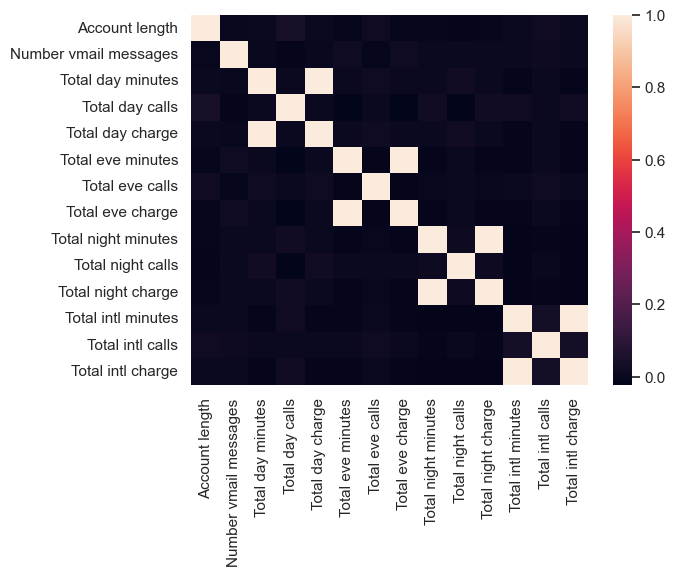

In [22]:
correlation_mat = df_1.corr()
sns.heatmap(correlation_mat)

Scatter Plot

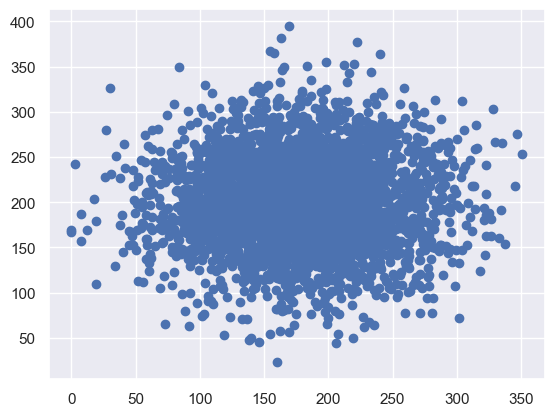

In [23]:
plt.scatter(df["Total day minutes"],df["Total night minutes"])

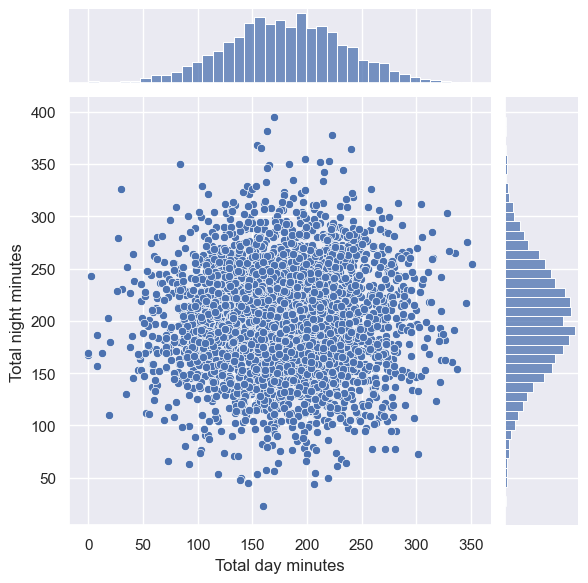

In [25]:
sns.jointplot(data = df,x = "Total day minutes",y = "Total night minutes",kind = "scatter")

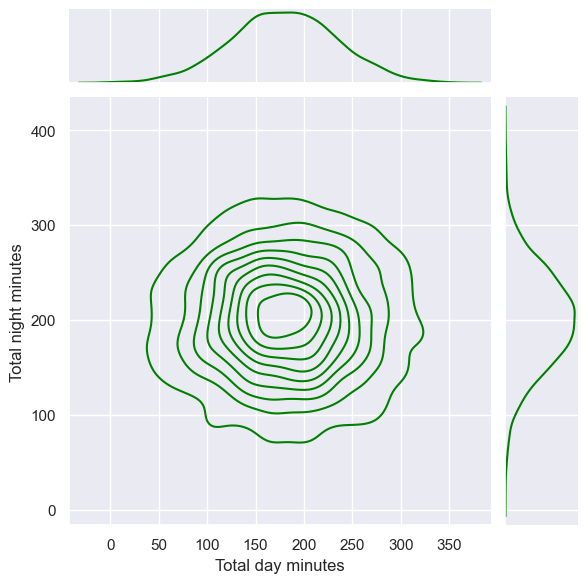

In [29]:
sns.jointplot(x ="Total day minutes",y = "Total night minutes",color = "green",data = df,kind="kde")

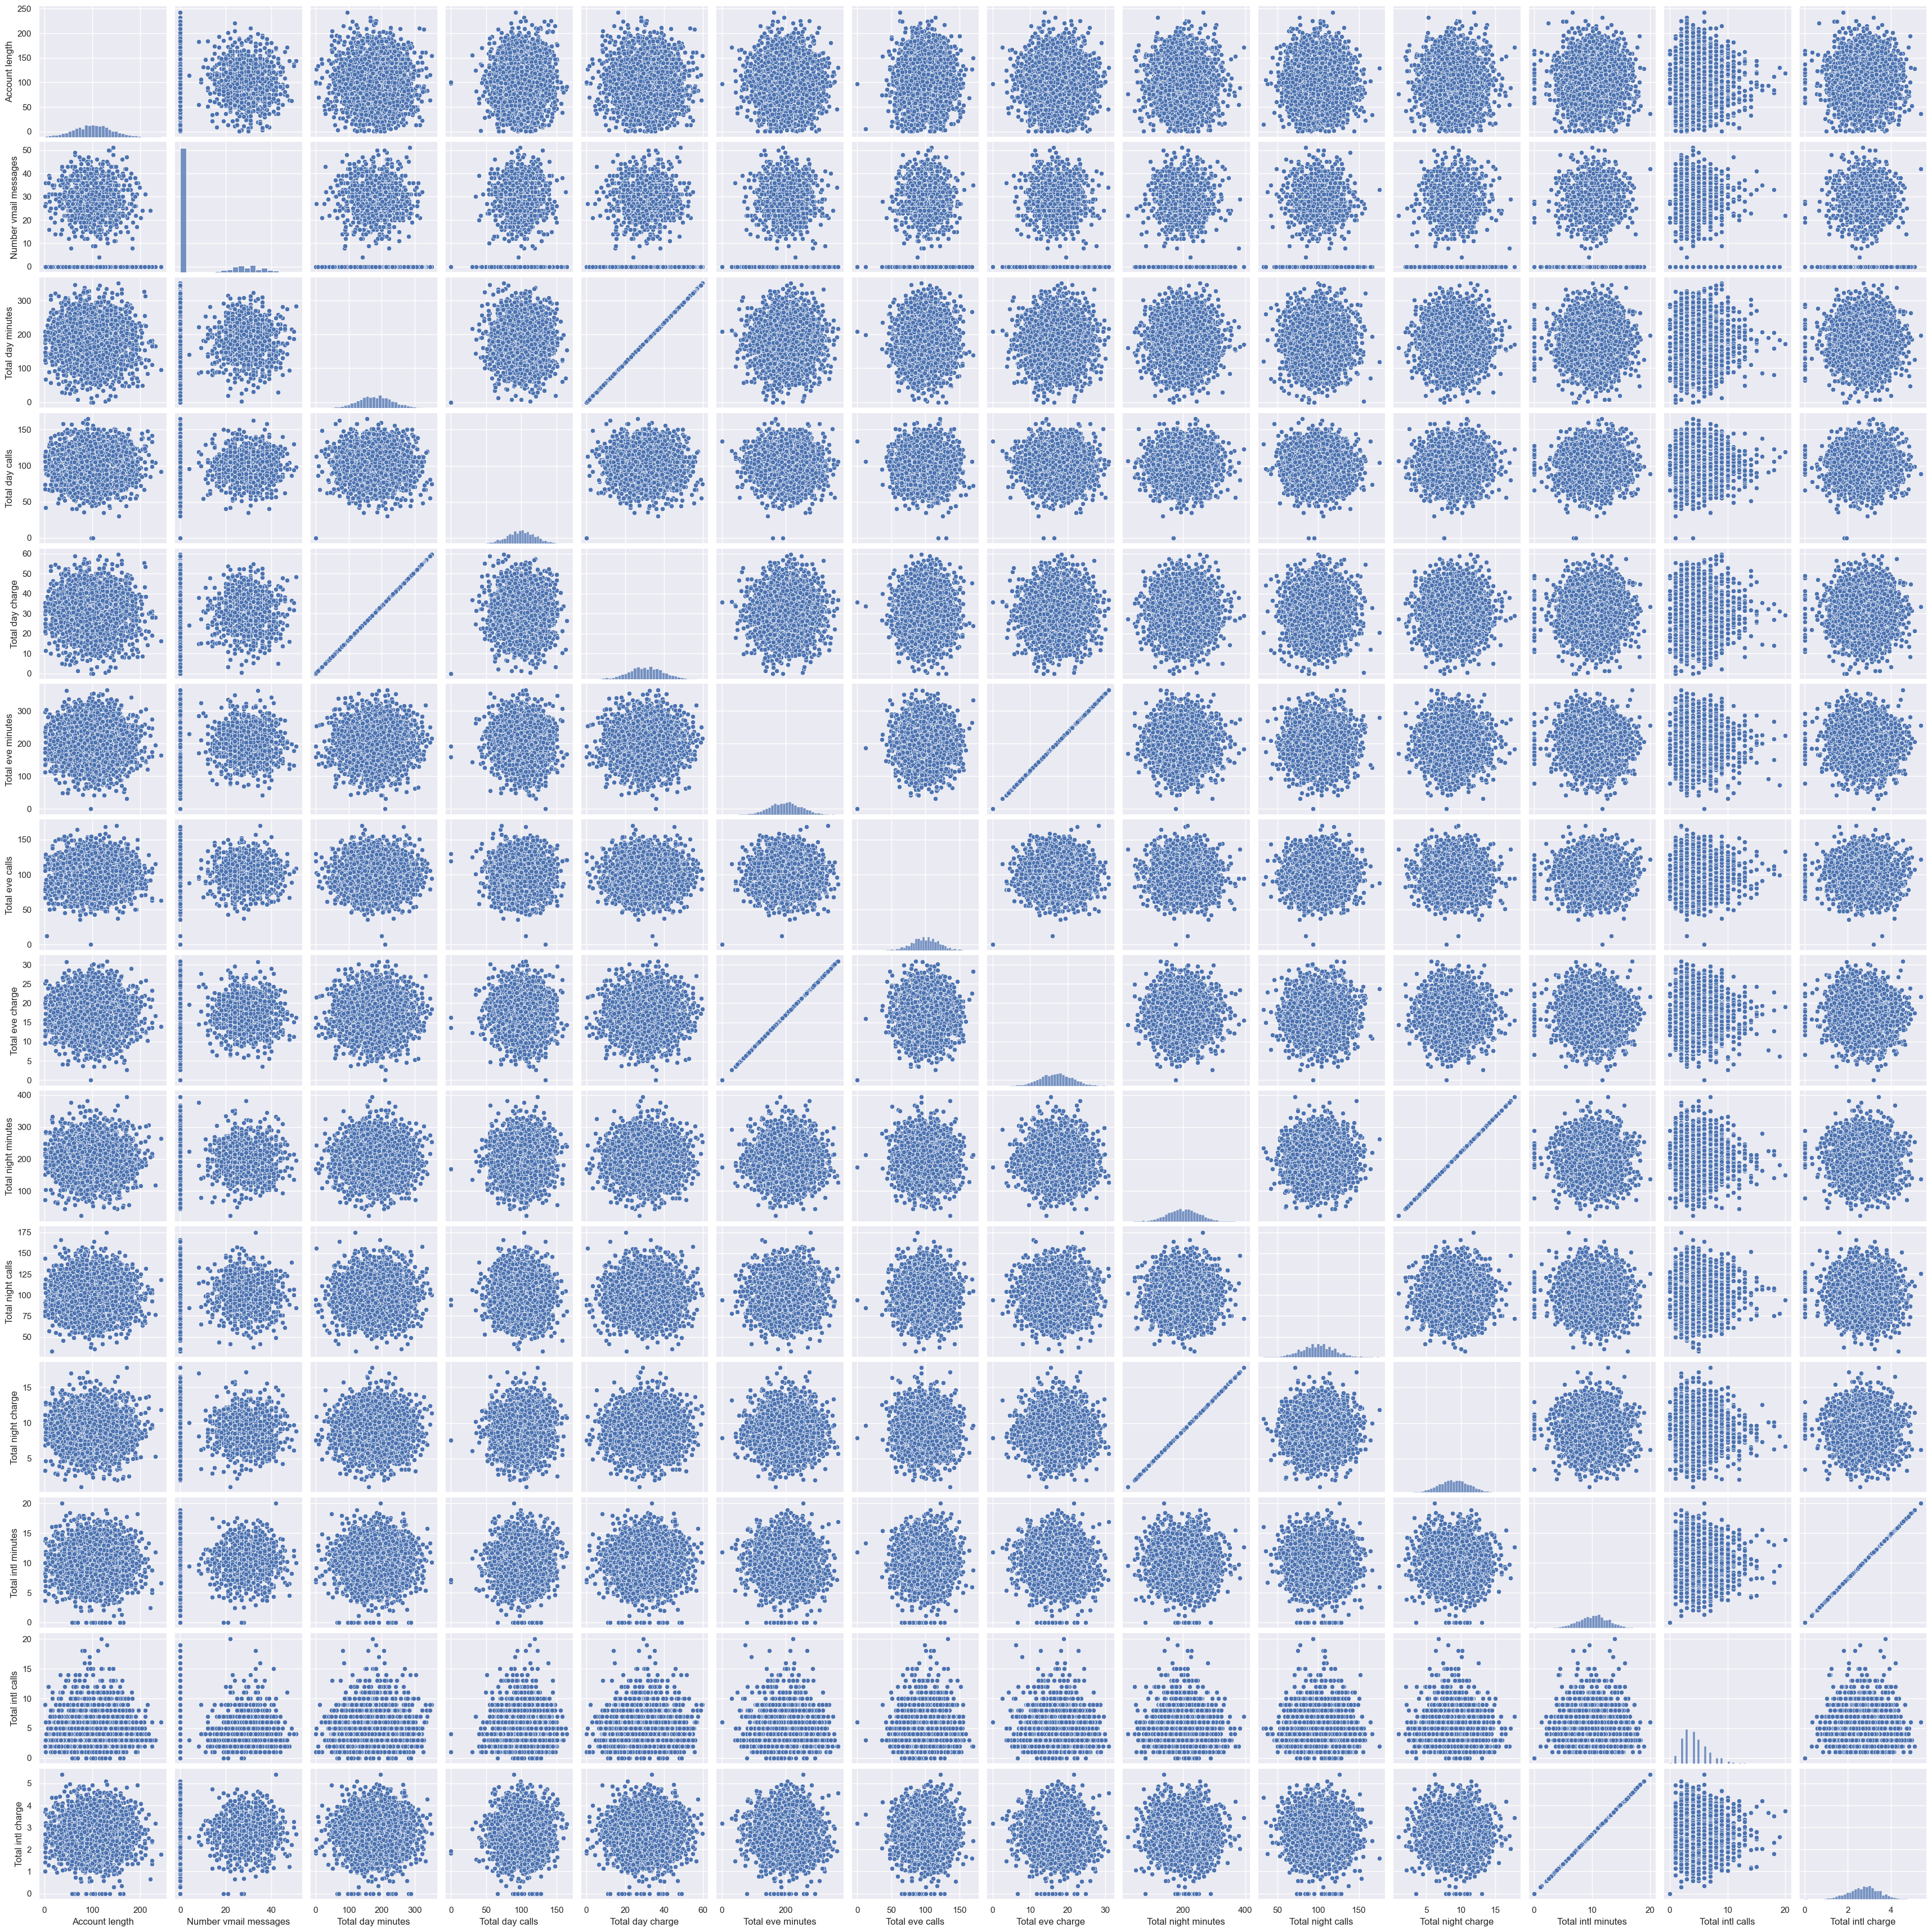

In [31]:
# Scatter plot matrix
sns.pairplot(df_1)

# Quantitative vs Categorical